# <span style="color:green"> Lecture 04 notebook </span>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## <span style="color:blue">  Exercise 04.1 </span>

La distribuzione delle velocitàm di Maxwell-Boltzmann è una distribuzione di probabilità utilizzata per descrivere la velocità delle particelle in gas ideali. In unità ridotte la formula risulta esserre 
$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}.$$

Per calcolare la POFV si è inserita la computazione di un istogramma all'interno dell'NSL SIMULATOR. Come velocità massima si è scelto il valore di $4\sqrt T$, e per determinare la grandezza dei bin si è diviso questo valore per il numero di bin, passato al programma nel file "properties.dat". Ad ogni step viene calcolato il modulo della velocità di ogni particella, che aumenta il contatore del bin corrispondente. Nel notebook i valori vengono normalizzati, ricostruendo in questo modo l'istogramma delle velocitò, che dovrebbe corrispondere alla distribuzione di Maxwell-Boltzmann per uno stato di equilibrio.

Per l'esercizio 4.1 sono stti simulati 20 blocchi da 2000 step ciascuno, partendo dalla seguente situazione:
- $108$ particelle;
- $T=1.2$;
- Configurazione FCC;
- $\rho=0.05$;
- $r_{cut}=5.0$;
- Velocità distribuite secondo una gaussiana con $\mu = 0$ e $\sigma = \sqrt T$.

In [4]:
#Plot per distribuzione di Maxwell-Boltzmann teorica
def maxwell_boltzmann(v, T):
    norm = 4.0 * np.pi * (1.0 / (2.0 * np.pi * T))**(3.0/2.0)
    return norm * (v**2) * np.exp(-v**2 / (2.0 * T))
    


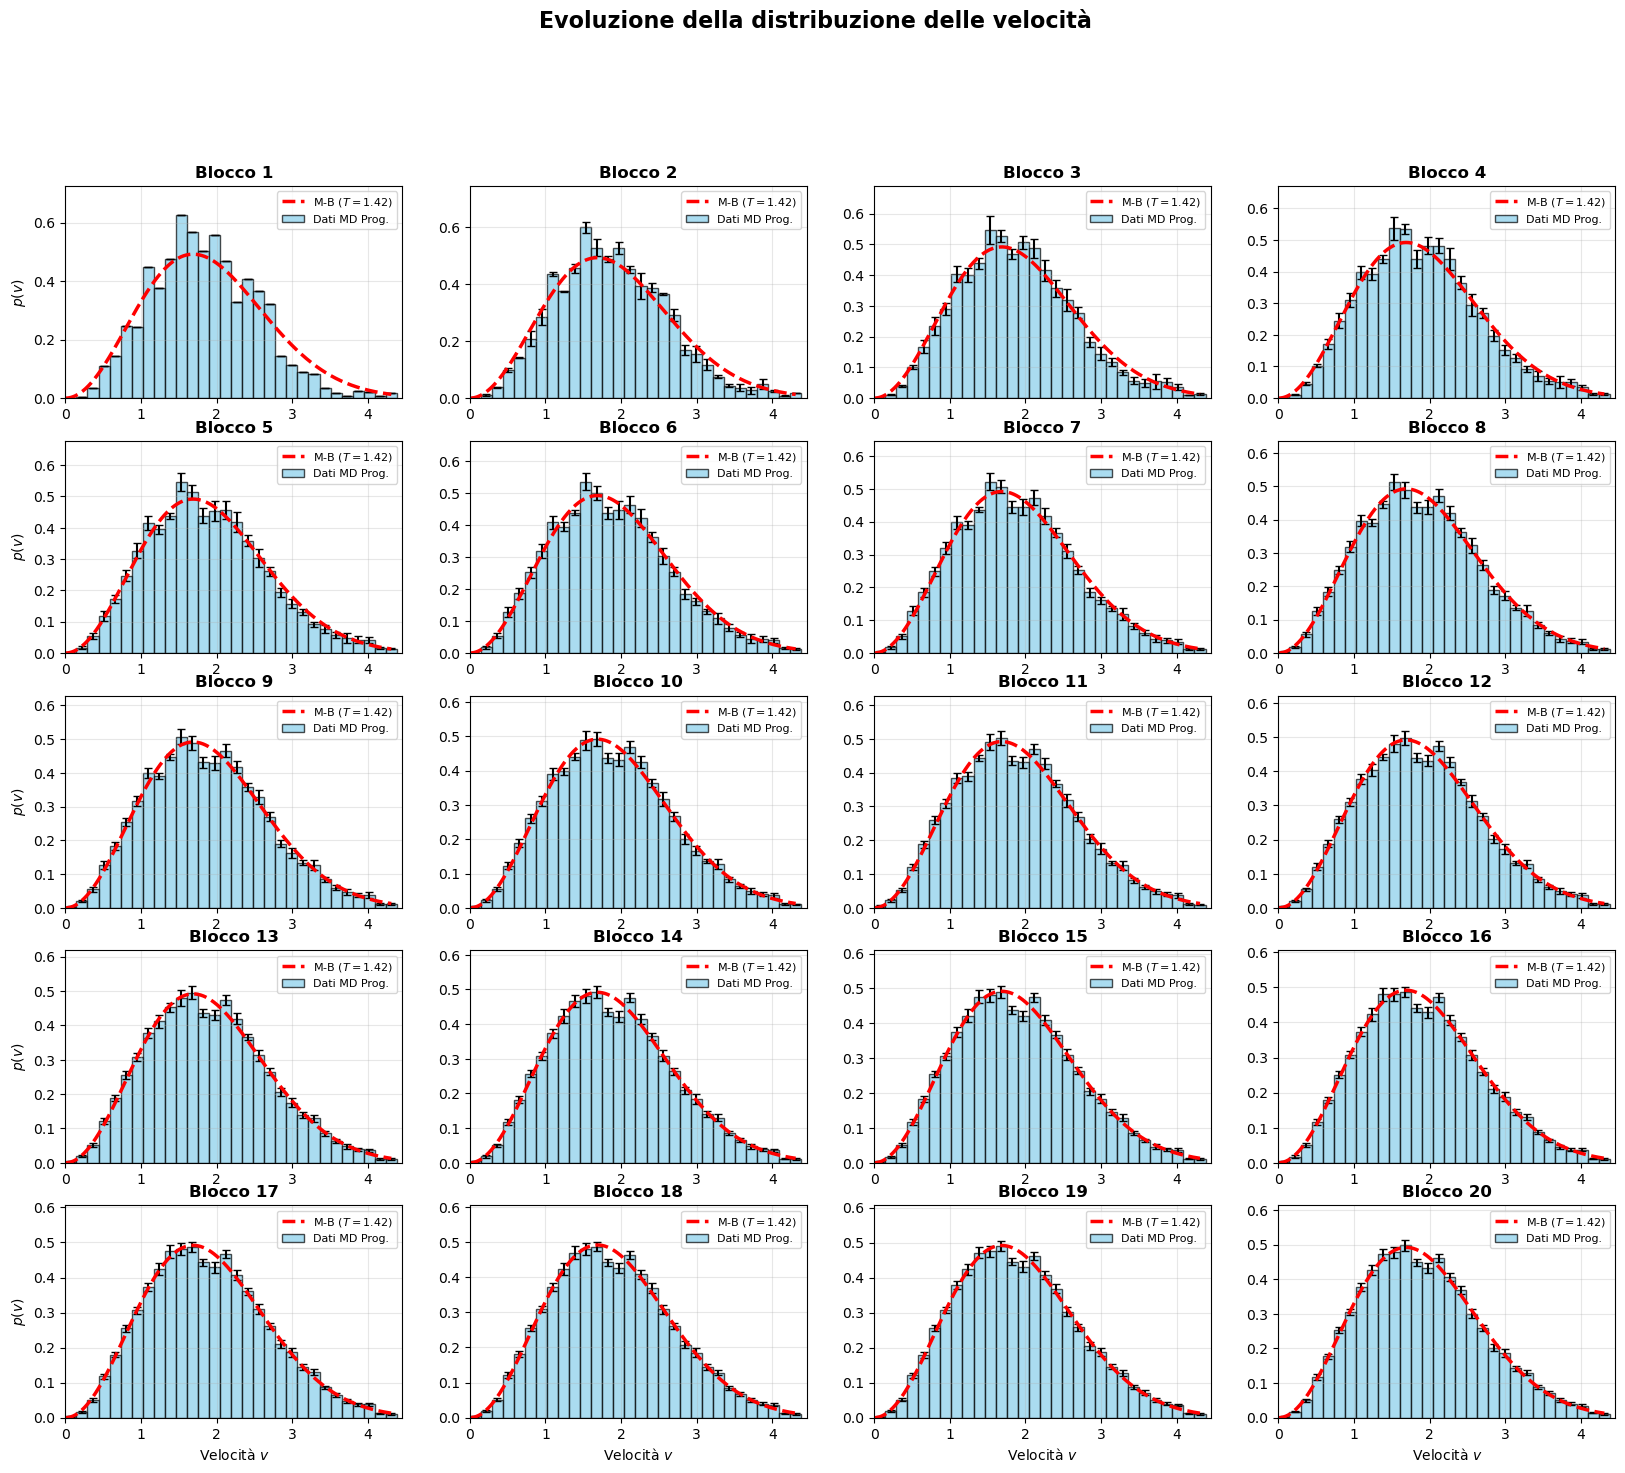

In [62]:
# Dati generali
N_part = 108   
n_bins = 30    
mass = 1.0 

#Esportazione temperatura
temp_data, err_temp = np.loadtxt("temperature4.1.dat", usecols = (2, 3), unpack = True)

#Esportazione dati relativi alle velocità e operazioni utili all'inizializzazione dell'istogramma
v, hist_prog, err_prog = np.loadtxt("pofv4.1.dat", usecols = (0, 2, 3), unpack = True)
n_blocks = 20
bin_size = v[1] - v[0]
v_blocks = v.reshape(n_blocks, n_bins)
hist_prog_blocks = hist_prog.reshape(n_blocks, n_bins)
err_prog_blocks = err_prog.reshape(n_blocks, n_bins)

#Inizializzazione figure
fig, axes = plt.subplots(5, 4, figsize=(20, 16))
axes = axes.flatten()

v_teorico = np.linspace(0, max(v), 500)
t = temp_data[-1]
p_teorico = maxwell_boltzmann (v_teorico, t)

for i in range(n_blocks):
    ax = axes[i]
    
    #Normalizzazione dei valori dell'istogramma e dei relativi errori
    hist_normalized = hist_prog_blocks / (N_part * bin_size)
    err_normalized = err_prog_blocks / (N_part * bin_size)
    
    #Rappresentazione istogramma
    ax.bar(v_blocks[i], hist_normalized[i], width=bin_size, align='center', color='skyblue', edgecolor='black', alpha=0.7, yerr=err_normalized[i], capsize=3, label='Dati MD Prog.')
    
    #Rappresentazione della curva teorica
    ax.plot(v_teorico, p_teorico, color='red', linewidth=2.5, linestyle='--', 
            label=f'M-B ($T={t:.2f}$)')

    
    ax.set_title(f"Blocco {i + 1}", fontsize=12, fontweight='bold')
    ax.set_xlim(0, max(v) + bin_size)
    ax.set_ylim(0, max(hist_normalized[i]) + max(err_normalized[i]) + 0.1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)
    
    if i >= 16: 
        ax.set_xlabel(r"Velocità $v$")
    if i % 4 == 0:  
        ax.set_ylabel(r"$p(v)$")

plt.suptitle("Evoluzione della distribuzione delle velocità", 
             fontsize=16, y=0.99, fontweight='bold')

plt.show()



Possiamo notare come la temperatura del sistema vada incontro a una correzione man mano che il sistema stesso raggiunge il proprio stato di equilibrio. Dopo 20 blocchi da 2000 passi il sistema ha raggiunto la distribuzione di equilibrio di Maxwell-Boltzmann.

## <span style="color:blue">  Exercise 04.2 </span>

Per l'esercizio 4.2 sono state utilizzate le seguenti condizioni di partenza:
- 108 particelle;
- $T = 2.0$;
- $r_{cut} = 5.0$;
- $\rho = 0.05$;
- Configurazione di partenza FCC in cubo di lato _halfside, quindi in un volume pari a $L^3/8$;
- Distribuzione delle velocità $p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$, con $v_{T^*} = \pm \sqrt{3 T^*}$ su una sola direzione.

Per eliminare il drift del sistema dovuto al momento totale $P$, la distribuzioen è stata in realtà leggermente sporcata, ma la scelta di una $v_{T^*}$ legata alla temperatura impostata ha permesso che questa correzione non modificasse significativamente la distribuzione.

Per osservare meglio l'evoluzione all'interno di ciascun blocco, l'evoluzione è stata condotta con $500$ blocchi da $50$ step ciascuno.


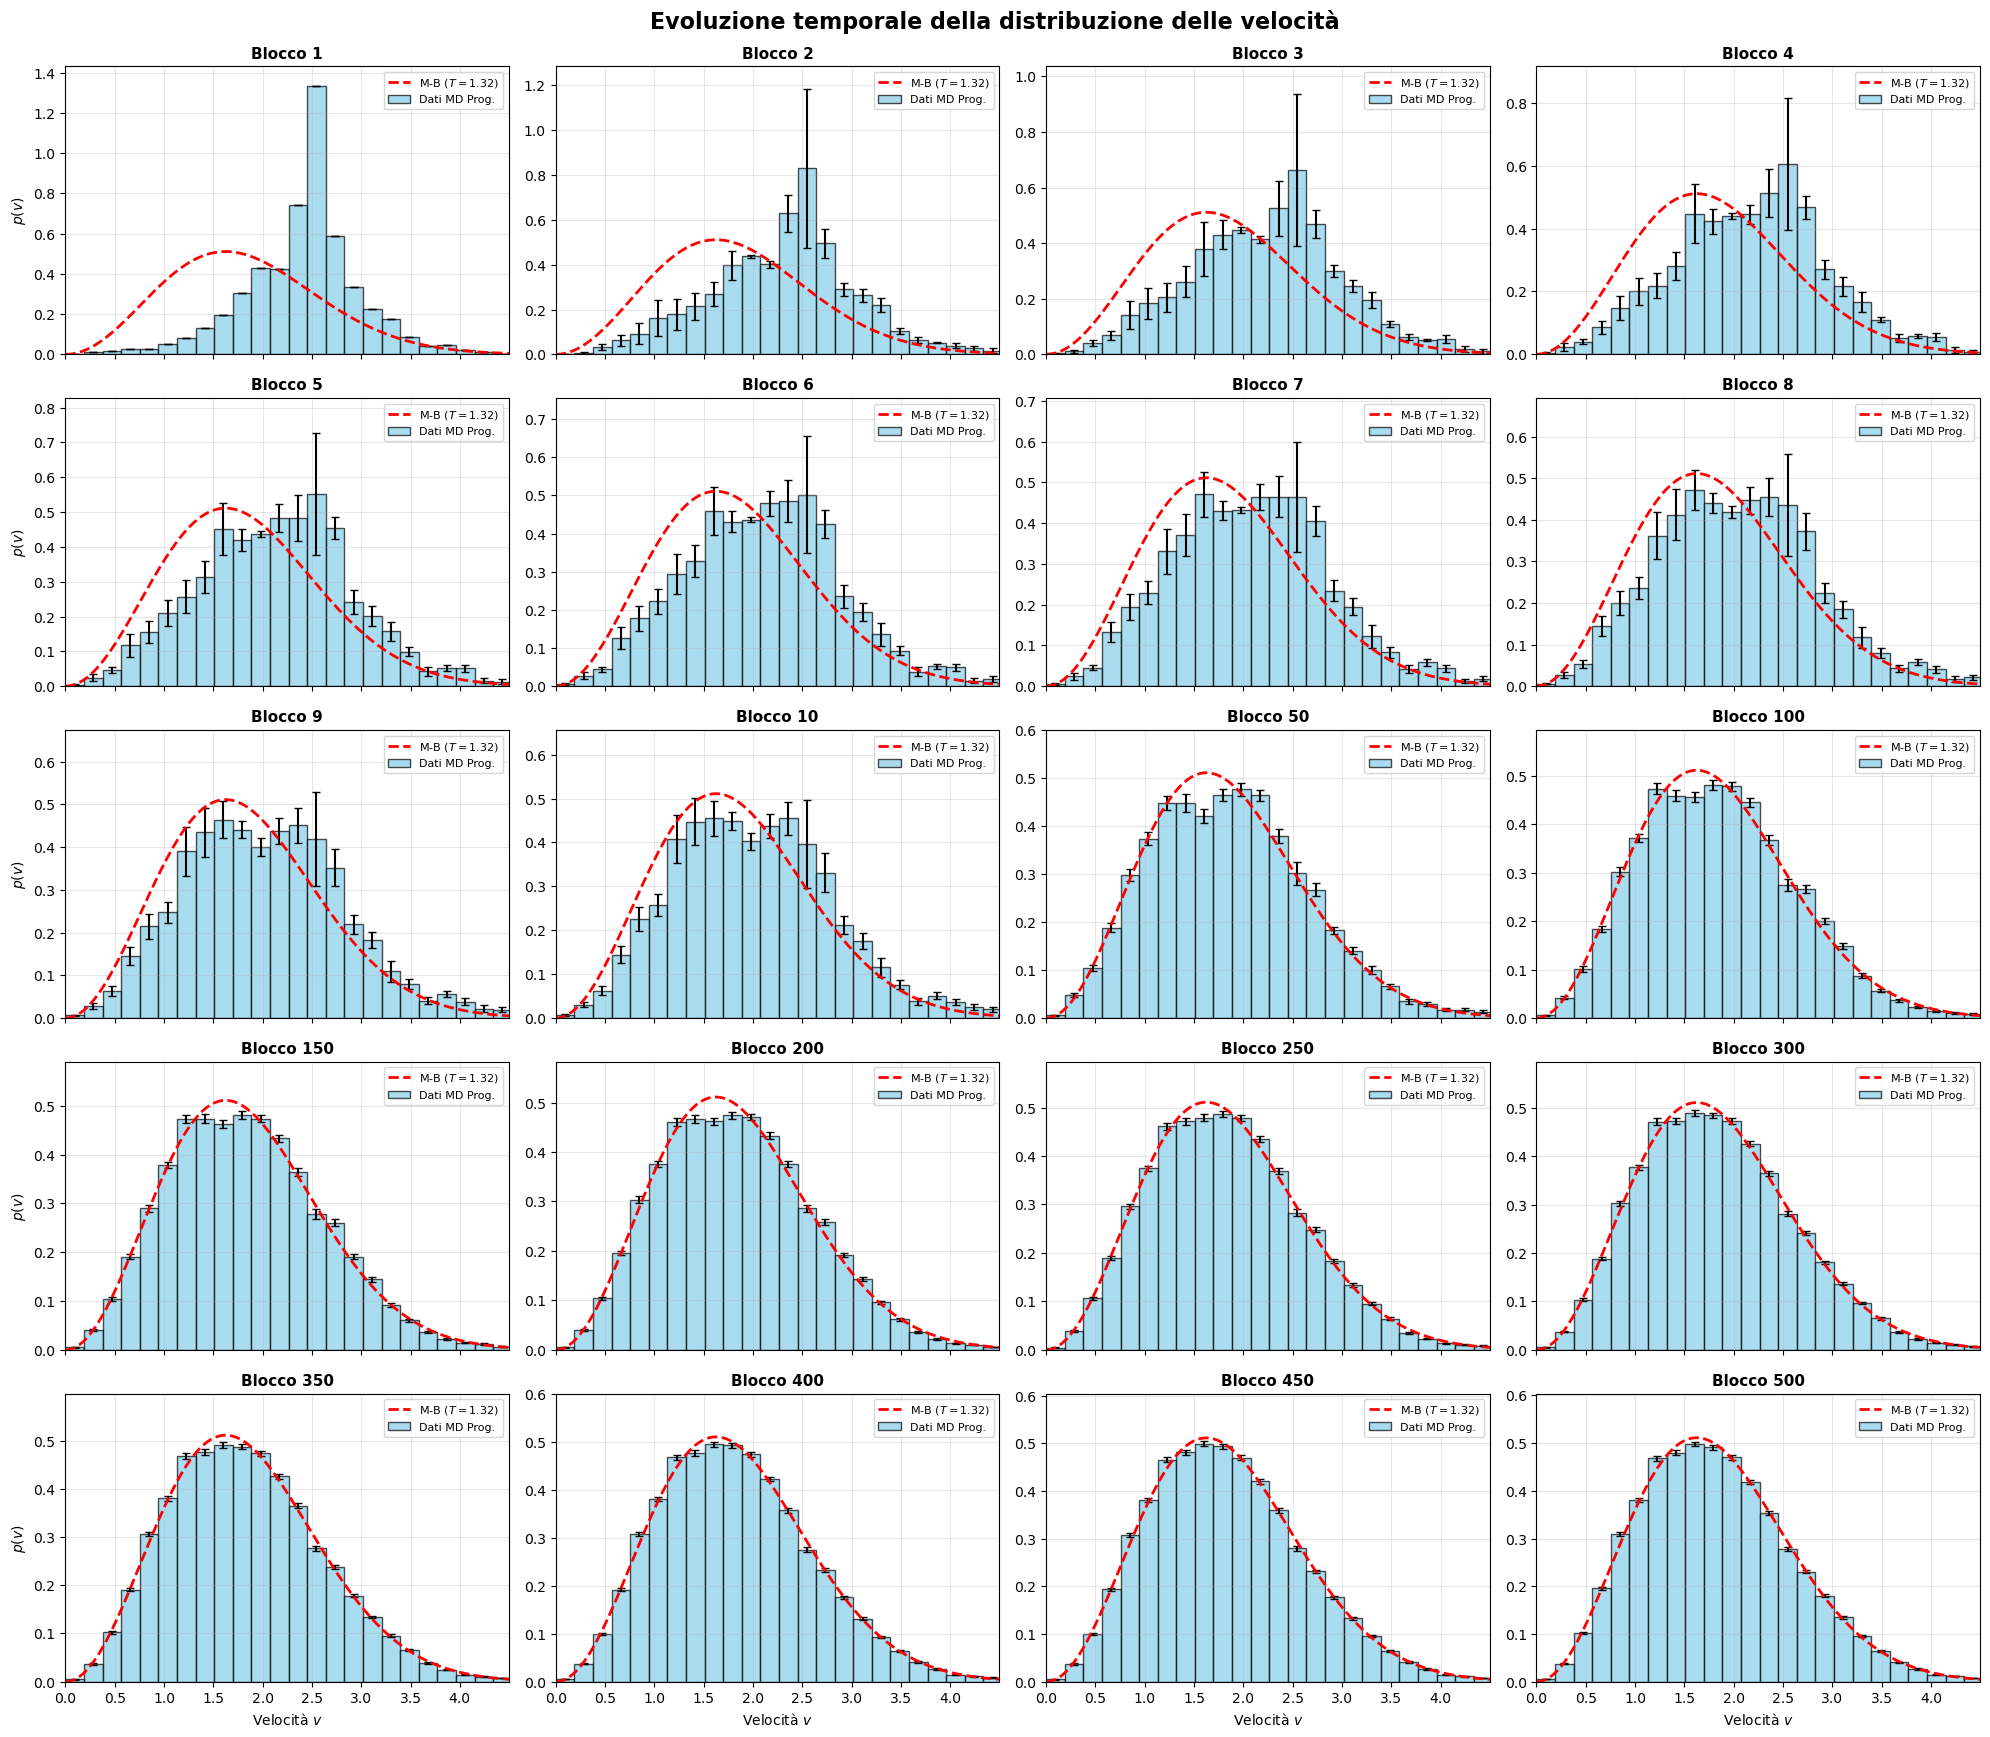

In [63]:
temp_data_2, err_temp_2 = np.loadtxt("temperature4.2(new).dat", usecols=(2, 3), unpack=True) 
v_2, hist_prog_2, err_prog_2 = np.loadtxt("pofv4.2(new).dat", usecols=(0, 2, 3), unpack=True)

n_blocks_2 = 500
n_bins = 30  
bin_size = v_2[1] - v_2[0]

v_blocks = v_2.reshape(n_blocks_2, n_bins)
hist_prog_blocks = hist_prog_2.reshape(n_blocks_2, n_bins)
err_prog_blocks = err_prog_2.reshape(n_blocks_2, n_bins)

blocchi_da_plottare = []
for b in range(1, n_blocks_2 + 1):
    if b <= 10:
        blocchi_da_plottare.append(b)
    elif b > 10 and b % 50 == 0:
        blocchi_da_plottare.append(b)

if 500 not in blocchi_da_plottare:
    blocchi_da_plottare.append(500)

n_cols = 4
n_rows = int(np.ceil(len(blocchi_da_plottare) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), sharex=True)
axes = axes.flatten()

v_teorico = np.linspace(0, max(v_2), 200)
t = temp_data_2[-1]
p_teorico = maxwell_boltzmann(v_teorico, t)

for idx, b in enumerate(blocchi_da_plottare):
    ax = axes[idx]
    i = b - 1  

    hist_normalized = hist_prog_blocks[i] / (N_part * bin_size)
    err_normalized = err_prog_blocks[i] / (N_part * bin_size)
    
    ax.bar(v_blocks[i], hist_normalized,  width=bin_size, align='center', color='skyblue', edgecolor='black', alpha=0.7, yerr=err_normalized, capsize=3, label='Dati MD Prog.')

    ax.plot(v_teorico, p_teorico, color='red', linewidth=2, linestyle='--', 
            label=f'M-B ($T={t:.2f}$)')

    # Estetica del grafico
    ax.set_title(f"Blocco {b}", fontsize=11, fontweight='bold')
    ax.set_xlim(0, max(v) + bin_size)
    ax.set_ylim(0, max(hist_normalized) + max(err_normalized) + 0.1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)
    
    if idx >= (len(blocchi_da_plottare) - n_cols): 
        ax.set_xlabel(r"Velocità $v$")
    if idx % n_cols == 0:  
        ax.set_ylabel(r"$p(v)$")

for j in range(len(blocchi_da_plottare), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Evoluzione temporale della distribuzione delle velocità", 
             fontsize=16, y=0.99, fontweight='bold')

plt.tight_layout()
plt.show()

[]

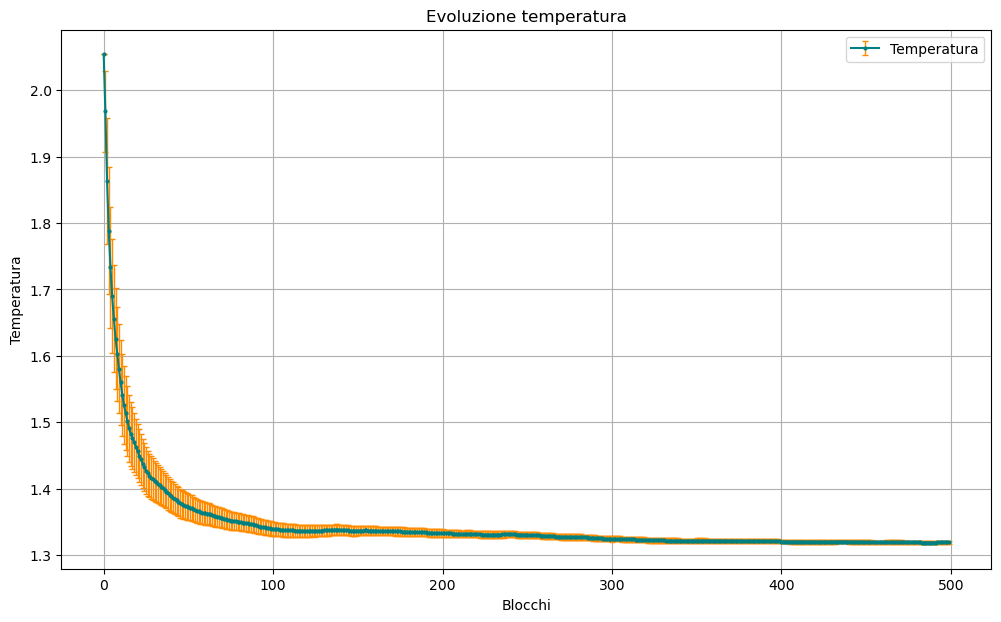

In [64]:
x = np.arange(n_blocks_2)

plt.figure(figsize=(12, 7))
plt.errorbar(x, temp_data_2, yerr = err_temp_2, fmt='o-', color='teal', ecolor='darkorange', elinewidth=1, capsize=2, markersize=2, label = "Temperatura")
plt.grid(True)
plt.title("Evoluzione temperatura")
plt.xlabel("Blocchi")
plt.ylabel("Temperatura")
plt.legend()

plt.plot()


Ho scelto di confrontare ogni istogramma della distribuzione delle velocità con la distribuzione di Maxwell-boltzmann alla temperatura progressiva finale.
Possiamo osservare come dop il primo blocco, ovvero dopo 50 step, la distribuzione delle velocità sia ancora fortemente legata alla distribuzione iniziale $p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$. Nei blocchi immediatamente successivi, durante i quali il sistema evolve rapidamente, notiamo come l'istogramma delle velocità tenda ad appiattirsi e ad avvicinarsi alla distribuzione di maxwell-Boltzmann, mentre la temperatura, progressivamente, cala. La barra d'errore associata alle colonne rappresentative della velocità inzialmente attribuita alle particelle risulta essere, naturalmente, molto grande in questi primi passaggi.

Osserviamo come all'aumentare dei blocchi la configurazione raggiunga l'equilibrio, avvicinandosi sempre di più alla distribuzione di Maxwell-Boltzmann, che può dirsi definitivamente raggiunta per gli ultimi blocchi.

L'evoluzione del sistema procede verso una confiurazione a maggior entropia, con le velocità delle particelle distribuite in modo più uniforme. 

Invertendo il tempo e quindi le velocità, da un punto di vista prettamente teorico mi aspetterei che il sistema tornasse nella configurazione a bassissima entropia: come discusso nell'esercizio successivo, le equazioni di Newton e l'algoritmo di Verlet sono simmetrici rispetto al tempo. Se facessi pochi passi nella mia simulazione, quindi dovrei riuscire a tornare nella configurazione iniziale. Per l'instabilità di Lyapunov, però, qualsiasi perturbazione porta le traiettorie delle particelle a divergere da quelle di "andata" esponenzialmente con il tempo. Nella nostra simulazione, questa perturbazione sono gli errori di rounding del calcolatore.

## <span style="color:blue">  Exercise 04.3 </span>

Temperatura iniziale: 2.02
Energia potenziale inizialei: -1.44
Temperatura dopo time reversal: 2.02 ± 0.05
Energia potenziale dopo time reversal: -1.44 ± 0.07


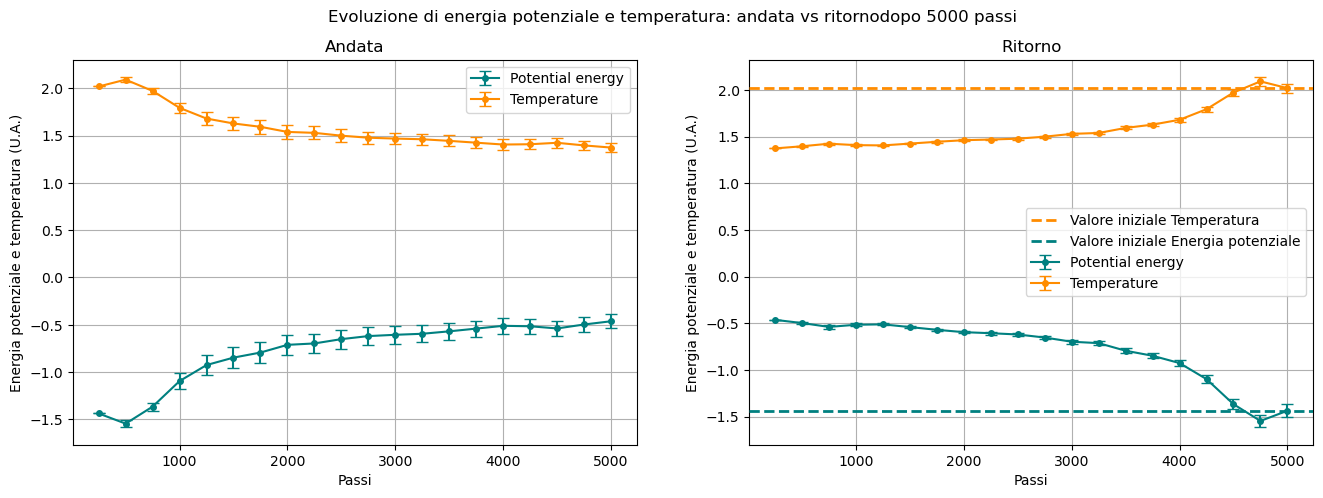

In [8]:
steps = 250

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

block, energy_a, error_a = np.loadtxt("potential_energy(1).dat", usecols = (0, 1, 3), unpack = True)
block, t_a, errort_a = np.loadtxt("temperature(1).dat", usecols = (0, 1, 3), unpack = True)
print(f'Temperatura iniziale: {t_a[0]:.2f}')
print(f'Energia potenziale inizialei: {energy_a[0]:.2f}')
axes[0].errorbar(block*steps, energy_a, yerr=error_a,  fmt='o-', color='teal', ecolor='teal', elinewidth=1.5, capsize=4, markersize=4, label = "Potential energy")
axes[0].errorbar(block*steps, t_a, yerr=errort_a,  fmt='o-', color='darkorange', ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, label = "Temperature")
axes[0].grid(True)
axes[0].set_title("Andata")
axes[0].set_xlabel("Passi")
axes[0].set_ylabel("Energia potenziale e temperatura (U.A.)")
axes[0].legend()

block, energy, error = np.loadtxt("potential_energy(2).dat", usecols = (0, 1, 3), unpack = True)
blockt, t, errort = np.loadtxt("temperature(2).dat", usecols = (0, 1, 3), unpack = True)

axes[1].errorbar(block*steps, energy, yerr=error,  fmt='o-', color='teal', ecolor='teal', elinewidth=1.5, capsize=4, markersize=4, label = "Potential energy")
axes[1].errorbar(block*steps, t, yerr=errort,  fmt='o-', color='darkorange', ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, label = "Temperature")
axes[1].grid(True)
axes[1].set_title("Ritorno")
axes[1].set_xlabel("Passi")
axes[1].set_ylabel("Energia potenziale e temperatura (U.A.)")
axes[1].axhline(t_a[0],  color='darkorange', linestyle='--', linewidth = 2, zorder = 10, label = 'Valore iniziale Temperatura')
axes[1].axhline(energy_a[0],  color='teal', linestyle='--', linewidth = 2, zorder = 10, label = 'Valore iniziale Energia potenziale')
axes[1].legend()
print(f"Temperatura dopo time reversal: {t[-1]:.2f} ± {errort[-1]:.2f}")
print(f"Energia potenziale dopo time reversal: {energy[-1]:.2f} ± {error[-1]:.2f}")


plt.suptitle('Evoluzione di energia potenziale e temperatura: andata vs ritornodopo 5000 passi')

plt.show()

Possiamo notare che dopo un'evoluzione di 5000 passi il sistema ritorna quasi perfettamente ai valori originari. In maniera interessante, l'incertezza dei dati del "ritorno" sembra essere sistematicamente più piccola rispetto ai dati dell'andata. Questo è in realtà un effetto dell'ordine in cui si susseguono i dati.

- All'andata, partendo da una configurazione a entropia bassissima, non appena il sistema viene lasciato libero di evolvere, le partcielle schizzano da ogni parte facendo variare molto velocemente i valori di energia potenziale e temperatura nei primissimi blocchi: i valori si discostano significativamente da quelli iniziali già dai primi blocchi, quando la varianza è poco smorzata dal numero dei blocchi al denominatore, facendola risultare prima che questa torni a ridursi.

- Al ritorno, invece, il sistema parte da una configurazione più vicina all'equilibrio, e i valori di temperatura e energia potenziale non variano molto fino a che non si arriva alla fne dell'evoluzione a ritroso, dove questi tornano ad essere simili a quelli corrispondenti alla configurazione a bassa entropia. A questo punto però, il numero dei blocchi è già alto, e la deviazione standard non si impenna più come aveva fatto all'andata.

Correttamente, comunque, il valore di incertezzafinale è lo stesso per entrambe le run.

Temperatura iniziale: 2.02
Energia potenziale iniziale: -1.44
Temperatura dopo time reversal: 1.32 ± 0.00
Energia potenziale dopo time reversal: -0.38 ± 0.00


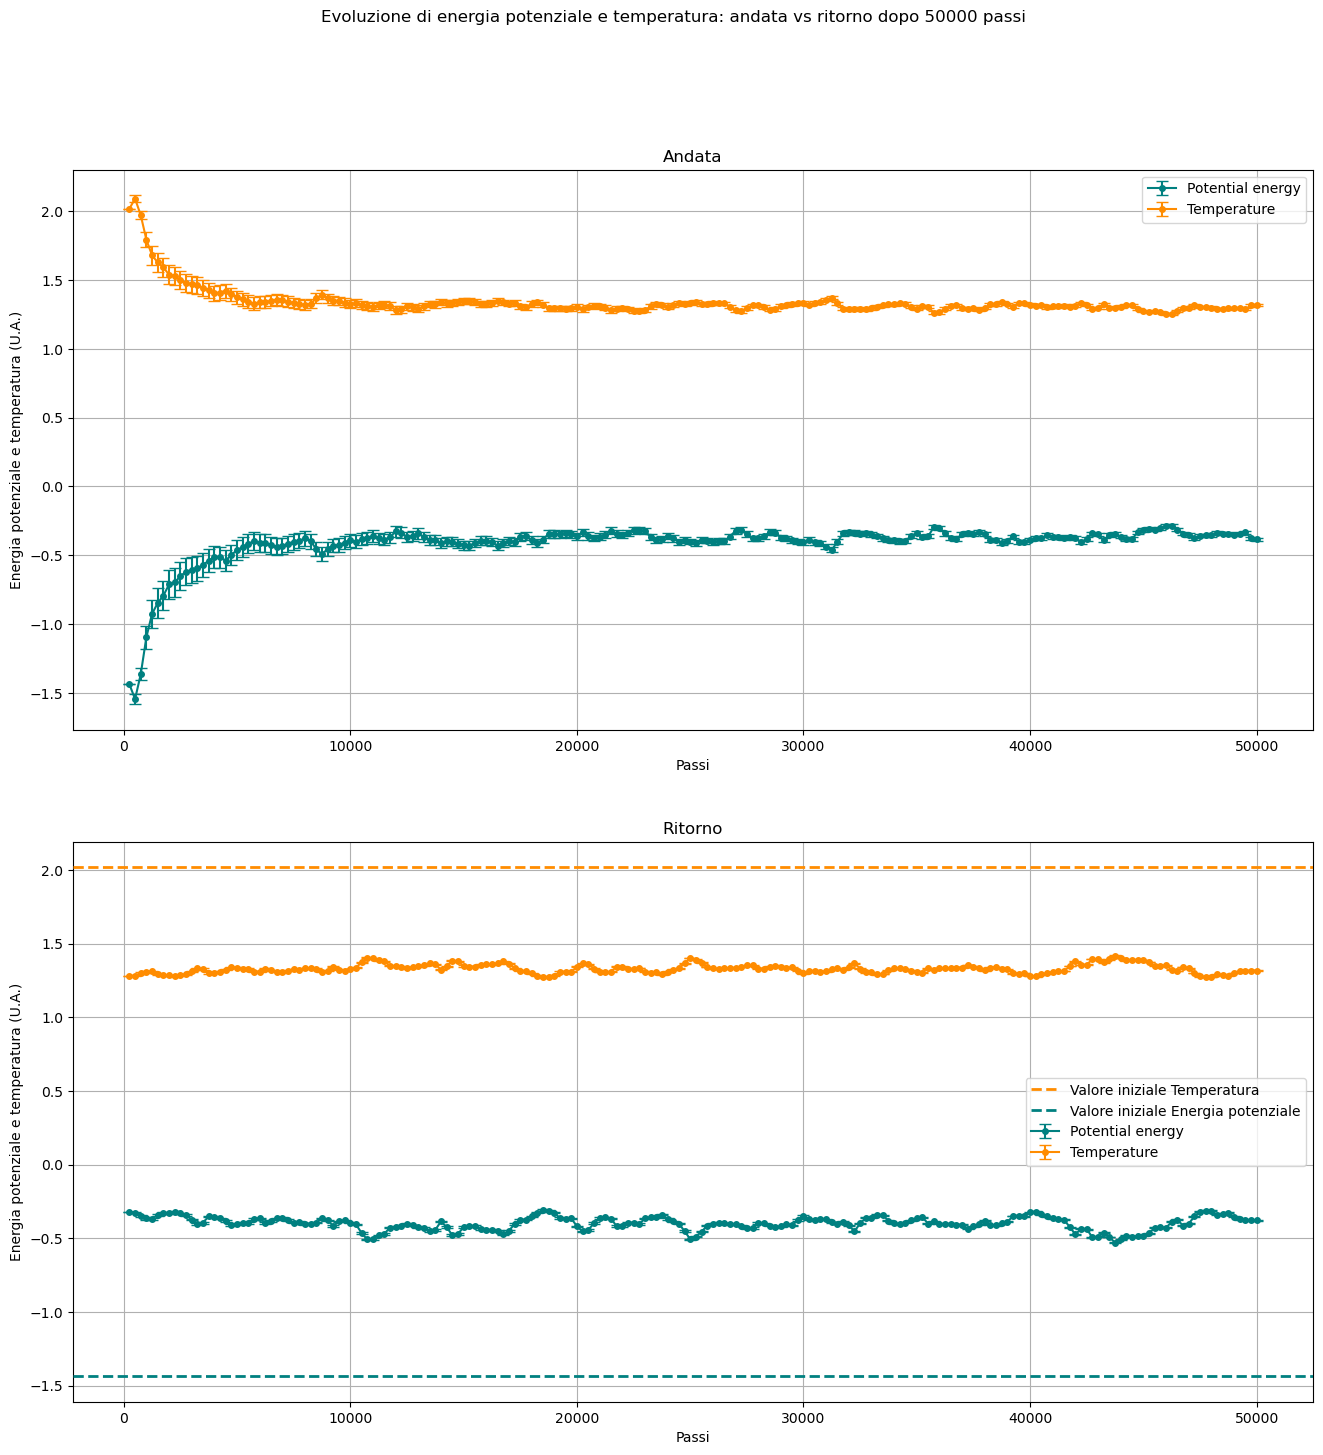

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 16))

block, energy_a, error_a = np.loadtxt("potential_energy(3).dat", usecols = (0, 1, 3), unpack = True)
block, t_a, errort_a = np.loadtxt("temperature(3).dat", usecols = (0, 1, 3), unpack = True)
print(f'Temperatura iniziale: {t_a[0]:.2f}')
print(f'Energia potenziale iniziale: {energy_a[0]:.2f}')
axes[0].errorbar(block*steps, energy_a, yerr=error_a,  fmt='o-', color='teal', ecolor='teal', elinewidth=1.5, capsize=4, markersize=4, label = "Potential energy")
axes[0].errorbar(block*steps, t_a, yerr=errort_a,  fmt='o-', color='darkorange', ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, label = "Temperature")
axes[0].grid(True)
axes[0].set_title("Andata")
axes[0].set_xlabel("Passi")
axes[0].set_ylabel("Energia potenziale e temperatura (U.A.)")
axes[0].legend()

block, energy, error = np.loadtxt("potential_energy(4).dat", usecols = (0, 1, 3), unpack = True)
blockt, t, errort = np.loadtxt("temperature(4).dat", usecols = (0, 1, 3), unpack = True)

axes[1].errorbar(block*steps, energy, yerr=error,  fmt='o-', color='teal', ecolor='teal', elinewidth=1.5, capsize=4, markersize=4, label = "Potential energy")
axes[1].errorbar(block*steps, t, yerr=errort,  fmt='o-', color='darkorange', ecolor='darkorange', elinewidth=1.5, capsize=4, markersize=4, label = "Temperature")
axes[1].grid(True)
axes[1].set_title("Ritorno")
axes[1].set_xlabel("Passi")
axes[1].set_ylabel("Energia potenziale e temperatura (U.A.)")
axes[1].axhline(t_a[0],  color='darkorange', linestyle='--', linewidth = 2, zorder = 10, label = 'Valore iniziale Temperatura')
axes[1].axhline(energy_a[0],  color='teal', linestyle='--', linewidth = 2, zorder = 10, label = 'Valore iniziale Energia potenziale')
axes[1].legend()
print(f"Temperatura dopo time reversal: {t[-1]:.2f} ± {errort[-1]:.2f}")
print(f"Energia potenziale dopo time reversal: {energy[-1]:.2f} ± {error[-1]:.2f}")


plt.suptitle('Evoluzione di energia potenziale e temperatura: andata vs ritorno dopo 50000 passi')

plt.show()

Dopo un'evoluzione di 50000 passi, invece, il sistema non riesce a recuperare i valori originari.

Come accennato in precedenza, i due comportamenti sono ragionevoli: le equazioni di Newton sono simetriche rispetto al tempo, e anche l'algoritmo del Verlet.

L'asimmetria delle grandezze misurate per invarianza temporale è dovuta agli errori di rounding del calcolatore, che su un periodo così lungo si accumulano e rendono impossibile ricostruire lo stato iniziale. Questo infatti calcola 

$$\vec{r}(t + dt) \approx 2\vec{r}(t) - \vec{r}(t-dt) + 2\delta t^2 \vec{a}(t),$$

in cui $\vec{r}(t+dt)$ e $\vec{r}(t-dt)$ giocano un ruolo simmetrico, rendendo l'algoritmo simmetrico rispetto al tempo. 

Ciò che rende le traiettorie instabili sono gli errori di rounding del computer, che per una simulazione più lunga si accumulano e portano le traiettorie a divergere, e i valori osservati a non ritornare sui propri passi. 

Questo comportamento conferma la natura statistica del concetto di entropia: è teoricamente possibile andare verso un'entropia più bassa, ma l'enorme abbondanza di stati disordinati rispetto all'unico ordinato previene che questo accada. 
Nella realtà non ci sono errori di rounding, ovviamente, ma le perturbazioni sono molte di più rispetto al nostro modello computazionale semplificato: quindi, invertendo il tempo, non ritorneremmo alla soluzione iniziale.
Il fatto che le equazioni di Newton fossero simmetriche rispetto al tempo ha dato origine al paradosso di Loschimdt, che criticava le teorie di Boltzmann, come brevemente descritto al link https://en.wikipedia.org/wiki/Loschmidt%27s_paradox.

Anche in questo caso è osservabile il comportamento delle incertezze illustrato in precedenza.